In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import defs
import re



In [430]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_colwidth', 20)

## File dowload

In [431]:
df = pd.read_csv('../data/_data.csv', encoding='utf-8')
df.head(5)

,Unnamed: 0,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Дом,Парковка,Цена,Телефоны,Описание,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление
0,0,271271157,4,Квартира,м. Смоленская (9...,"Москва, улица Но...",200.0/20.0,"5/16, Монолитный",подземная,500000.0 руб./ З...,+79166369231,Без комиссии для...,Дизайнерский,NaN,NaN,NaN,NaN,"Можно с детьми, ...",Мебель в комната...,"Новый Арбат, 2010",NaN,3.0,"Пасс (4), Груз (1)",Да,https://www.cian...
1,1,271634126,4,Квартира,м. Смоленская (8...,"Москва, улица Но...",198.0/95.0/18.0,"5/16, Монолитно-...",подземная,500000.0 руб./ З...,+79850608590,Лот 93107. Елена...,Дизайнерский,25 25 20 25,NaN,На улицу и двор,"Совмещенный (2),...",Можно с детьми,Мебель в комната...,Новый Арбат,NaN,3.5,"Пасс (1), Груз (1)",Нет,https://www.cian...
2,2,271173086,"4, Оба варианта",Квартира,м. Смоленская (7...,"Москва, улица Но...",200.0/116.0/4.0,5/16,подземная,500000.0 руб./ З...,"+79672086536, +7...",ID 36380: Шикар...,Евроремонт,NaN,NaN,На улицу и двор,Совмещенный (3),Можно с детьми,Мебель в комната...,Новый Арбат,NaN,3.2,Пасс (1),NaN,https://www.cian...
3,3,272197456,"4, Оба варианта",Квартира,м. Смоленская (3...,"Москва, переулок...",170.0/95.0/17.0,5/6,подземная,400000.0 руб./ З...,"+79660342340, +7...",ID 31618: Экскл...,Евроремонт,14-42-20-19,NaN,На улицу и двор,Совмещенный (3),Можно с животными,Мебель в комната...,NaN,NaN,3.2,Пасс (1),NaN,https://www.cian...
4,4,273614615,2,Квартира,м. Арбатская (7 ...,"Москва, улица Но...",58.0/38.0/5.0,"12/26, Панельный",NaN,225000.0 руб./ З...,+79852432860,Лот 111542. Тать...,Евроремонт,20 18,NaN,На улицу и двор,Совмещенный (2),NaN,Мебель в комната...,The Book,NaN,3.9,"Пасс (1), Груз (1)",Да,https://www.cian...


In [432]:
df = df.drop(columns=['Unnamed: 0'])
df = df.reset_index(drop=True)


## таблица уникальных значений в каждой колонке и их количество

In [433]:
for column in df.columns.tolist(): 
    print (column)
    print (df[column].value_counts(dropna=False))

ID  объявления
ID  объявления
271271157    1
271634126    1
271173086    1
272197456    1
273614615    1
            ..
215565511    1
274654844    1
268679909    1
274807525    1
274672243    1
Name: count, Length: 23368, dtype: int64
Количество комнат
Количество комнат
1                   7917
2, Изолированная    4623
2                   2591
3                   1717
3, Изолированная    1583
NaN                 1041
3, Оба варианта      875
4                    674
2, Смежная           637
2, Оба варианта      615
4, Оба варианта      253
5                    235
4, Изолированная     223
6                     87
3, Смежная            87
5, Оба варианта       81
5, Изолированная      47
6, Оба варианта       31
6, Изолированная      17
4, Смежная            13
1, Изолированная       8
1, Оба варианта        4
5, Смежная             4
6, Смежная             3
1, Смежная             2
Name: count, dtype: int64
Тип
Тип
Квартира    23368
Name: count, dtype: int64
Метро
Метро
NaN          

## переназывание колонок

In [434]:
df.columns=['Ad_ID', 'Number_of_rooms', 'Type', 'Metro', 'Address',
 'Area_m2', 'Building', 'Parking', 'Price', 'Phones', 'Description',
 'Renovation', 'Room_area_m2', 'Balcony', 'Windows', 'Bathroom',
 'Children/pets_allowed', 'Additional', 'Residential_complex_name',
 'Building_series', 'Ceiling_height_m', 'Elevator', 'Garbage_chute',
 'Ad_link']
ya_i_columns = ['Ad_ID', 'Description', 'Renovation', 'Room_area_m2', 'Balcony', 'Windows', 'Bathroom', 'Children/pets_allowed']

In [435]:
# Обработать колонки:
# Description	
# (+) Renovation	
# (+) Room_area_m2	
# (+) Balcony	
# (+) Windows	
# (+) Bathroom	
# (+) Children/pets_allowed
# Очистить от NaN
# Добавить Dummy-кодирование 

def extract_numbers(text):
    if pd.isna(text):
        return []
    numbers_str = re.findall(r'\d+(?:[.,]\d+)?', str(text))
    return [float(x.replace(',', '.')) for x in numbers_str]

def sum_func(text):
    if pd.isna(text):
        return 0
    numbers = re.findall(r'\((\d+)\)', text)
    return sum(int(num) for num in numbers)

ya_i_df = df[ya_i_columns]

ya_i_df['Renovation'] = ya_i_df['Renovation']

ya_i_df['Room_area_m2'] = ya_i_df['Room_area_m2'].apply(extract_numbers)

ya_i_df['Balcony'] = ya_i_df['Balcony'].str.replace(r'\s*\(\d+\)', '', regex=True)
ya_i_df['Balcony_count'] = ya_i_df['Balcony'].apply(sum_func)

ya_i_df['Bathroom'] = ya_i_df['Bathroom'].str.replace(r'\s*\(\d+\)', '', regex=True)
ya_i_df['Bathroom_count'] = ya_i_df['Bathroom'].apply(sum_func)

ya_i_df['Description']

ya_i_df['Renovation'].unique()


<StringArray>
['Дизайнерский', 'Евроремонт', 'Косметический', nan, 'Без ремонта']
Length: 5, dtype: str

In [436]:
df['Renovation'] = df['Renovation']

df['Room_area_m2'] = df['Room_area_m2'].apply(extract_numbers)

df['Balcony_count'] = df['Balcony'].apply(sum_func)
df['Balcony'] = df['Balcony'].str.replace(r'\s*\(\d+\)', '', regex=True)

df['Bathroom_count'] = df['Bathroom'].apply(sum_func)
df['Bathroom'] = df['Bathroom'].str.replace(r'\s*\(\d+\)', '', regex=True)

df['Bathroom_count']

0        0
1        3
2        3
3        3
4        2
        ..
23363    1
23364    1
23365    1
23366    2
23367    1
Name: Bathroom_count, Length: 23368, dtype: int64

In [437]:
df['Number_of_rooms_int'] = df['Number_of_rooms'].apply(lambda x : defs.cutter(x,','))
df['Type of room'] = df['Number_of_rooms'].apply(lambda x : defs.cutter(x,',', index_start=1, index_end= None))

In [438]:
df= df.drop('Number_of_rooms', axis=1)

In [439]:
df['extra_money'] = df['Price'].apply(lambda x: defs.cutter(x,'/', index_start=1, index_end = None))
df['Price'] = df['Price'].apply(lambda x: defs.cutter(x,'/'))


In [440]:
df['Price']=df['Price'].apply(defs.re_money)

In [441]:
df['Full_area']= df['Area_m2'].apply(lambda x: defs.cutter(x,'/')).astype(float)
df['Rooms_area'] = df['Area_m2'].apply(lambda x: x.split('/')[1:] if len(x.split('/'))>1 else None)
df=df.drop('Area_m2', axis=1)

In [442]:
df['Float_floor']= df["Building"].apply(lambda x: defs.extract_pattern(x, pattern = r'\d+/\d+')).apply(lambda x: defs.cutter(x, '/'))
df['Height_building']= df["Building"].apply(lambda x: defs.extract_pattern(x, pattern = r'\d+/\d+')).apply(lambda x: defs.cutter(x, '/', index_start=1, index_end=None))
df['Building_type'] = df['Building'].apply(lambda x: defs.cutter(x, ',', index_start=1, index_end=None))

In [443]:
df = df.drop('Building', axis=1)


In [444]:
df

,Ad_ID,Type,Metro,Address,Parking,Price,Phones,Description,Renovation,Room_area_m2,Balcony,Windows,Bathroom,Children/pets_allowed,Additional,Residential_complex_name,Building_series,Ceiling_height_m,Elevator,Garbage_chute,Ad_link,Balcony_count,Bathroom_count,Number_of_rooms_int,Type of room,extra_money,Full_area,Rooms_area,Float_floor,Height_building,Building_type
0,271271157,Квартира,м. Смоленская (9...,"Москва, улица Но...",подземная,500000.0,+79166369231,Без комиссии для...,Дизайнерский,[],NaN,NaN,NaN,"Можно с детьми, ...",Мебель в комната...,"Новый Арбат, 2010",NaN,3.00,"Пасс (4), Груз (1)",Да,https://www.cian...,0,0,4,,"За месяц, Залог...",200.0,[20.0],5,16,Монолитный
1,271634126,Квартира,м. Смоленская (8...,"Москва, улица Но...",подземная,500000.0,+79850608590,Лот 93107. Елена...,Дизайнерский,"[25.0, 25.0, 20....",NaN,На улицу и двор,"Совмещенный, Раз...",Можно с детьми,Мебель в комната...,Новый Арбат,NaN,3.50,"Пасс (1), Груз (1)",Нет,https://www.cian...,0,3,4,,"За месяц, Залог...",198.0,"[95.0, 18.0]",5,16,Монолитно-кирпи...
2,271173086,Квартира,м. Смоленская (7...,"Москва, улица Но...",подземная,500000.0,"+79672086536, +7...",ID 36380: Шикар...,Евроремонт,[],NaN,На улицу и двор,Совмещенный,Можно с детьми,Мебель в комната...,Новый Арбат,NaN,3.20,Пасс (1),NaN,https://www.cian...,0,3,4,Оба варианта,"За месяц, Залог...",200.0,"[116.0, 4.0]",5,16,
3,272197456,Квартира,м. Смоленская (3...,"Москва, переулок...",подземная,400000.0,"+79660342340, +7...",ID 31618: Экскл...,Евроремонт,"[14.0, 42.0, 20....",NaN,На улицу и двор,Совмещенный,Можно с животными,Мебель в комната...,NaN,NaN,3.20,Пасс (1),NaN,https://www.cian...,0,3,4,Оба варианта,"За месяц, Залог...",170.0,"[95.0, 17.0]",5,6,
4,273614615,Квартира,м. Арбатская (7 ...,"Москва, улица Но...",NaN,225000.0,+79852432860,Лот 111542. Тать...,Евроремонт,"[20.0, 18.0]",NaN,На улицу и двор,Совмещенный,NaN,Мебель в комната...,The Book,NaN,3.90,"Пасс (1), Груз (1)",Да,https://www.cian...,0,2,2,,"За месяц, Залог...",58.0,"[38.0, 5.0]",12,26,Панельный
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23363,215565511,Квартира,м. Говорово (8 м...,"Москва, Боровско...",NaN,42000.0,+79154383401,Сдаётся светлая ...,Евроремонт,[],Балкон,NaN,Совмещенный,NaN,Мебель в комната...,Мещерский лес,NaN,NaN,"Пасс (1), Груз (1)",NaN,https://www.cian...,1,1,NaN,NaN,"За месяц, Залог...",35.0,"[16.4, 8.0]",10,14,
23364,274654844,Квартира,м. Солнцево (7 м...,"Москва, Производ...",NaN,45000.0,+79151173402,Сдам однокомнатн...,Евроремонт,[],Лоджия,Во двор,Совмещенный,NaN,Мебель в комната...,Лучи,NaN,NaN,"Пасс (1), Груз (1)",NaN,https://www.cian...,1,1,1,,"За месяц, Залог...",38.7,"[16.5, 11.0]",5,18,Монолитный
23365,268679909,Квартира,м. Солнцево (6 м...,"Москва, Боровски...",NaN,50000.0,+79653825192,Рассматриваются ...,Дизайнерский,[],Балкон,На улицу и двор,Совмещенный,Можно с детьми,"Мебель на кухне,...",NaN,NaN,NaN,NaN,NaN,https://www.cian...,1,1,2,Оба варианта,"За месяц, Залог...",43.1,None,5,5,Кирпичный
23366,274807525,Квартира,м. Солнцево (11 ...,"Москва, улица Бо...",наземная,55000.0,+79660611965,Двухкомнатная ую...,Евроремонт,[],Лоджия,Во двор,"Совмещенный, Раз...",NaN,Мебель в комната...,NaN,NaN,2.65,Пасс (3),Да,https://www.cian...,1,2,2,,"За месяц, Залог...",52.5,[10.0],8,23,Монолитный


In [445]:
df = df[~df['Address'].str.lower().str.startswith('санкт-петербург', na=False)]

### Garbage_chute

In [446]:
# df["Garbage_chute"] = df["Garbage_chute"].replace({"Да":1, "Нет":0})
df["Garbage_chute(yes)"] = df["Garbage_chute"].eq("Да")
df["Garbage_chute(no)"] = df["Garbage_chute"].eq("Нет")

df["Garbage_chute(yes)"] = df["Garbage_chute(yes)"].astype(int)
df["Garbage_chute(no)"] = df["Garbage_chute(no)"].astype(int)

### Ceiling_height_m

In [447]:
df.loc[df["Ceiling_height_m"] > 100, "Ceiling_height_m"] /= 100
df.loc[df["Ceiling_height_m"] > 24.9, "Ceiling_height_m"] /= 10

df["Ceiling_height_m"] = df["Ceiling_height_m"][(df["Ceiling_height_m"] > 2.4) & (df["Ceiling_height_m"] < 6)]

### Elevator

In [448]:
df["pass_elev"] = df["Elevator"].str.extract(r"Пасс\s*\((\d+)\)").fillna(0).astype(int)
df["cargo_elev"] = df["Elevator"].str.extract(r"Груз\s*\((\d+)\)").fillna(0).astype(int)
df["elevator_more_2"] = (df["pass_elev"]+df["cargo_elev"] >= 2).astype(int)


### f

In [449]:
df = df.drop(["Elevator", "Residential_complex_name", "Building_series", "Garbage_chute"], axis=1)

In [450]:
df.info()

<class 'pandas.DataFrame'>
Index: 20340 entries, 0 to 23367
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ad_ID                  20340 non-null  int64  
 1   Type                   20340 non-null  str    
 2   Metro                  19391 non-null  str    
 3   Address                20340 non-null  str    
 4   Parking                8748 non-null   str    
 5   Price                  20340 non-null  float64
 6   Phones                 20340 non-null  str    
 7   Description            20340 non-null  str    
 8   Renovation             17872 non-null  str    
 9   Room_area_m2           20340 non-null  object 
 10  Balcony                13478 non-null  str    
 11  Windows                14963 non-null  str    
 12  Bathroom               18147 non-null  str    
 13  Children/pets_allowed  15275 non-null  str    
 14  Additional             20047 non-null  str    
 15  Ceiling_height_m  

## Распределение количества кваритир по количеству комнат

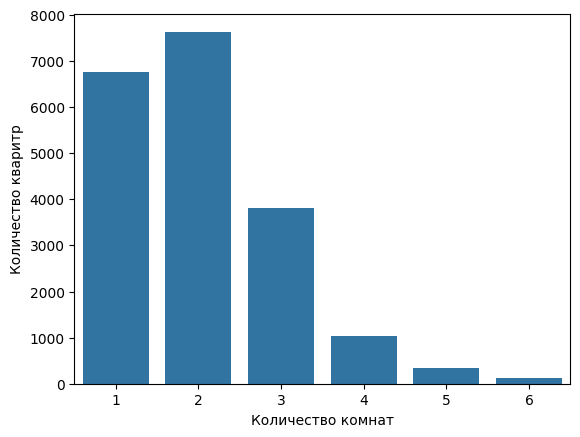

In [451]:

fig, ax = plt.subplots()
sns.barplot(data = df.groupby('Number_of_rooms_int', as_index=False).count() , x ='Number_of_rooms_int', y = 'Ad_ID' )
ax.set_xlabel('Количество комнат')
ax.set_ylabel('Количество кваритр')
plt.show()


In [452]:
#df.to_csv('../data/data_v0_1.csv', encoding='utf-8')

## Зависимость цены от площади

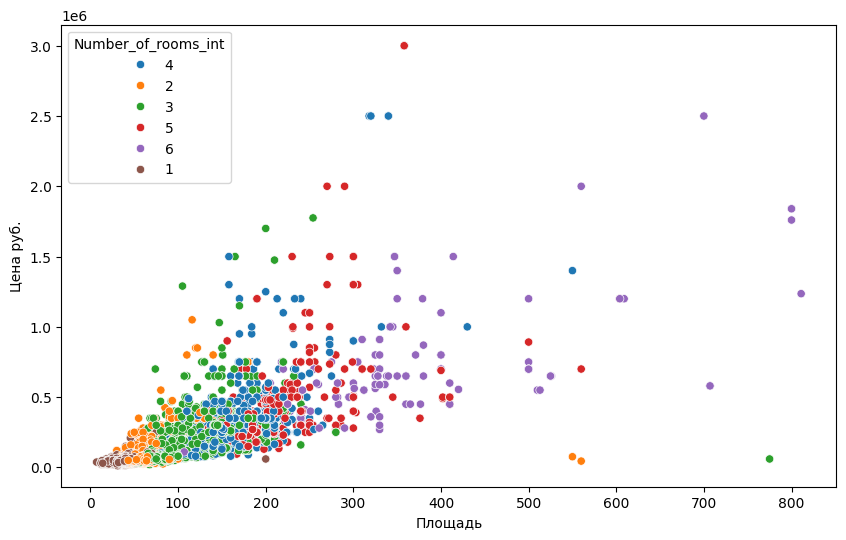

In [453]:
fig, ax = plt.subplots(figsize = (10,6))
sns.scatterplot(df, x = 'Full_area', y='Price', hue = 'Number_of_rooms_int')

ax.set_xlabel('Площадь')
ax.set_ylabel('Цена руб.')
plt.show()

## Зависимость цены от станции метро 

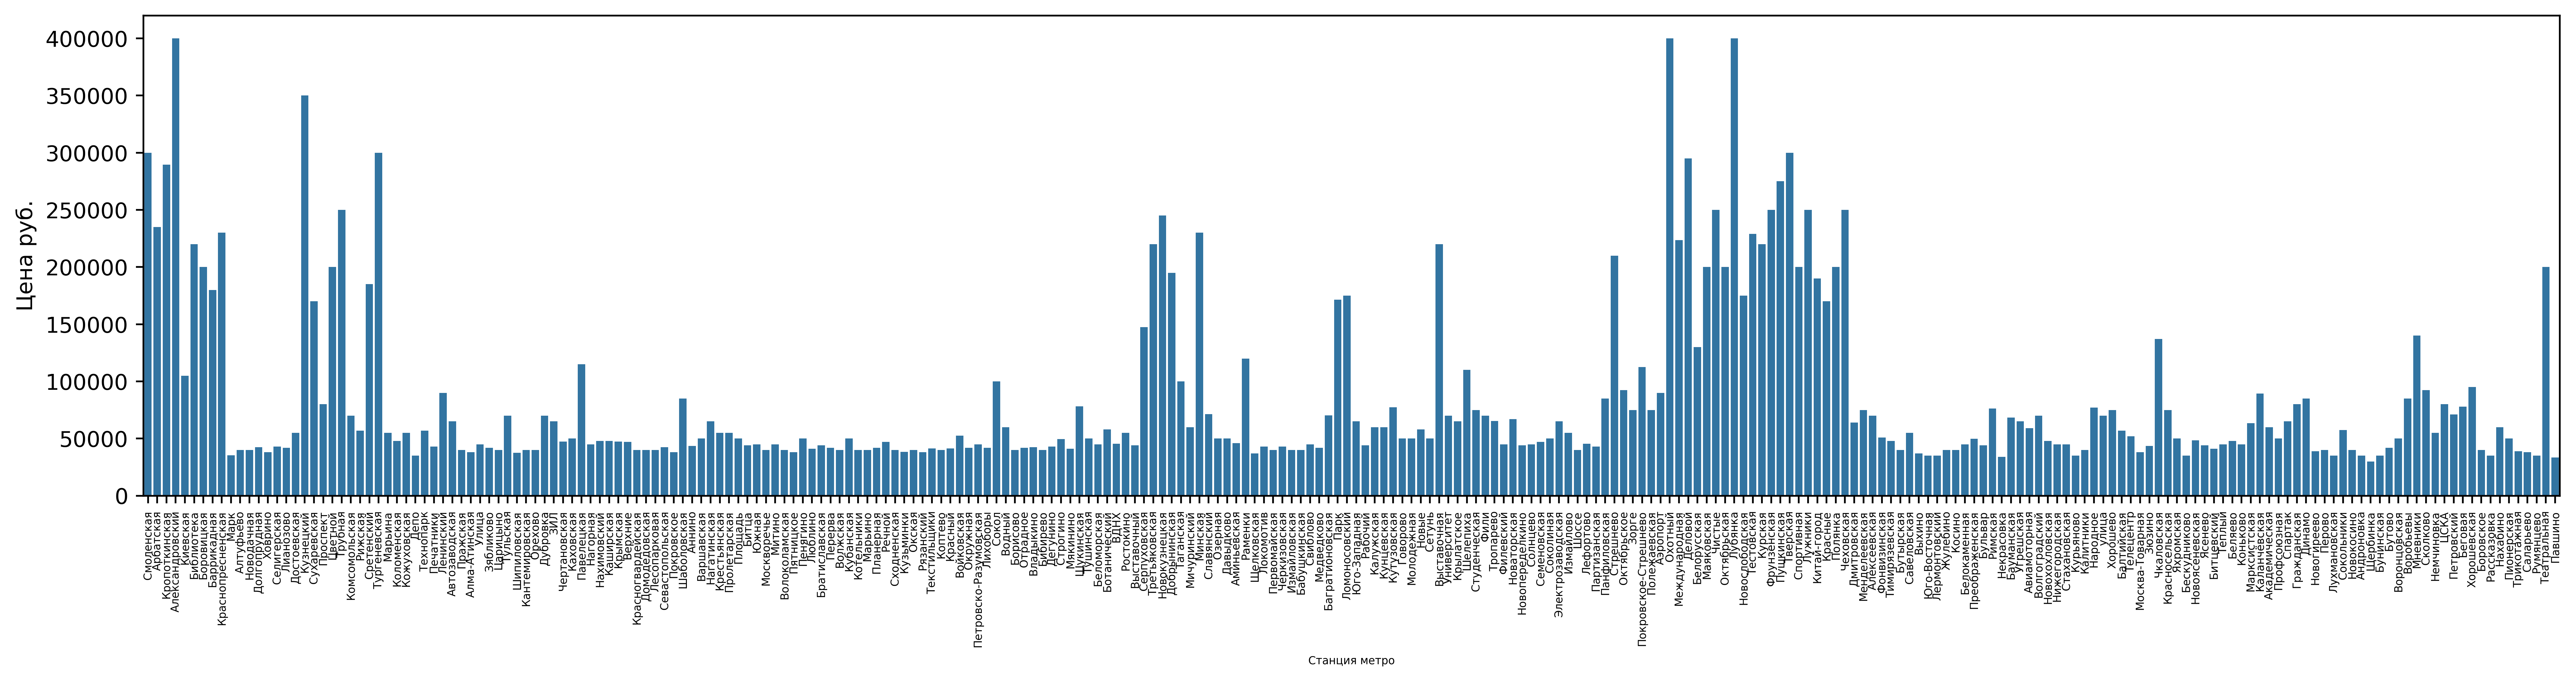

In [454]:
df_metro = df['Metro'].apply(lambda x : defs.cutter(x,' ', index_start= 1, index_end=2))
fig, ax = plt.subplots(figsize = (20,4), dpi = 500)
sns.barplot(df, x = df_metro, y='Price', errorbar = None, estimator= 'median')
plt.xticks(rotation = 90)
ax.tick_params(axis='x', labelsize=5)
ax.set_xlabel('Станция метро',size=5)
ax.set_ylabel('Цена руб.')
plt.show()

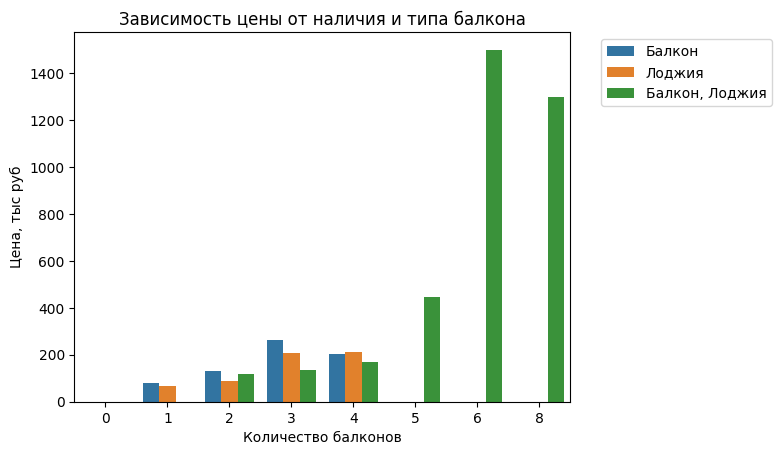

<Figure size 768x576 with 0 Axes>

In [455]:
ax = sns.barplot(
    data=df,
    x='Balcony_count',
    y=df['Price']/1000,
    hue='Balcony',
    errorbar=None
)

ax.set(
    title='Зависимость цены от наличия и типа балкона',
    xlabel='Количество балконов',
    ylabel='Цена, тыс руб'
    )

ax.legend(
    bbox_to_anchor=(1.42, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

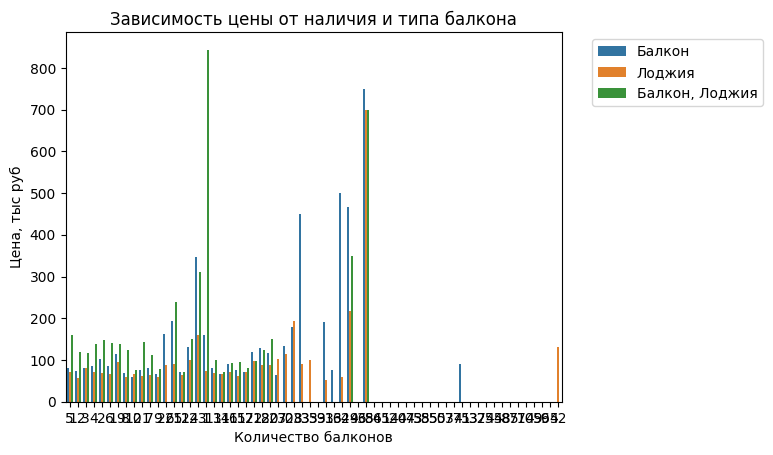

<Figure size 768x576 with 0 Axes>

In [456]:
ax = sns.barplot(
    data=df,
    x='Float_floor',
    y=df['Price']/1000,
    hue='Balcony',
    errorbar=None
)

ax.set(
    title='Зависимость цены от наличия и типа балкона',
    xlabel='Количество балконов',
    ylabel='Цена, тыс руб'
    )

ax.legend(
    bbox_to_anchor=(1.42, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

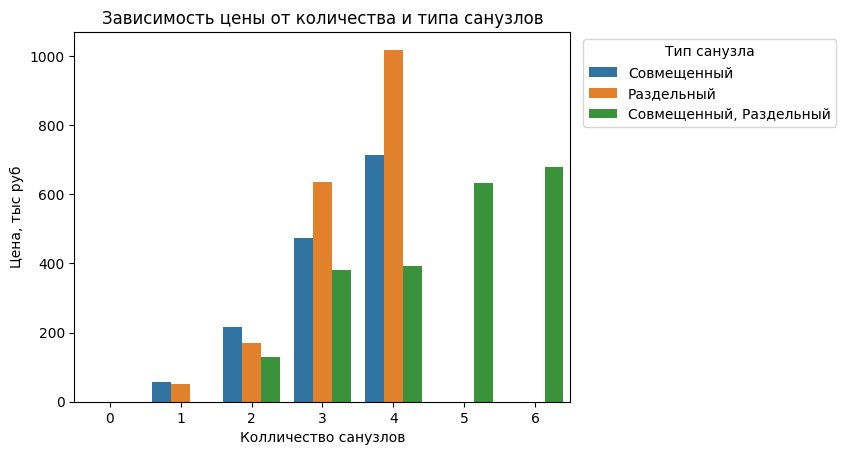

<Figure size 768x576 with 0 Axes>

In [457]:
ax = sns.barplot(
    data=df,
    x='Bathroom_count',
    y=df['Price']/1000,
    hue='Bathroom',
    errorbar=None
)

ax.set(
    title='Зависимость цены от количества и типа санузлов',
    xlabel='Колличество санузлов',
    ylabel='Цена, тыс руб',
    )

ax.legend(
    title='Тип санузла',
    bbox_to_anchor=(1.55, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

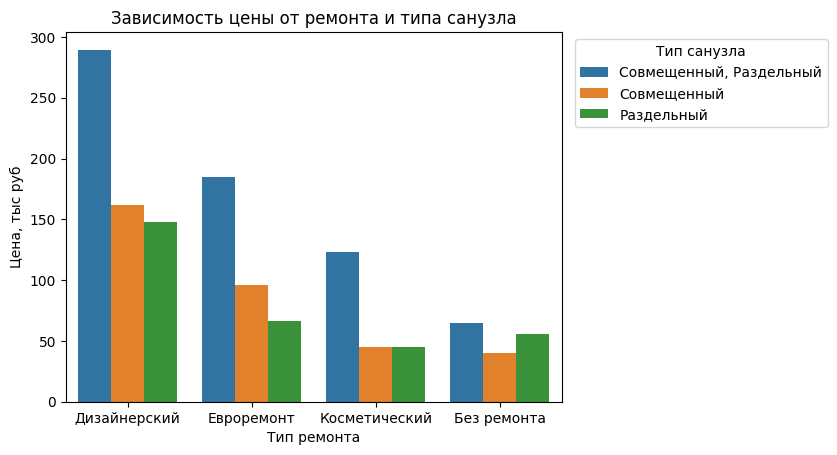

<Figure size 768x576 with 0 Axes>

In [458]:
ax = sns.barplot(
    data=df,
    x='Renovation',
    y=df['Price']/1000,
    hue='Bathroom',
    errorbar=None
)

ax.set(
    title='Зависимость цены от ремонта и типа санузла',
    xlabel='Тип ремонта',
    ylabel='Цена, тыс руб',
    )

ax.legend(
    title='Тип санузла',
    bbox_to_anchor=(1.55, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

## Тепловая карта 

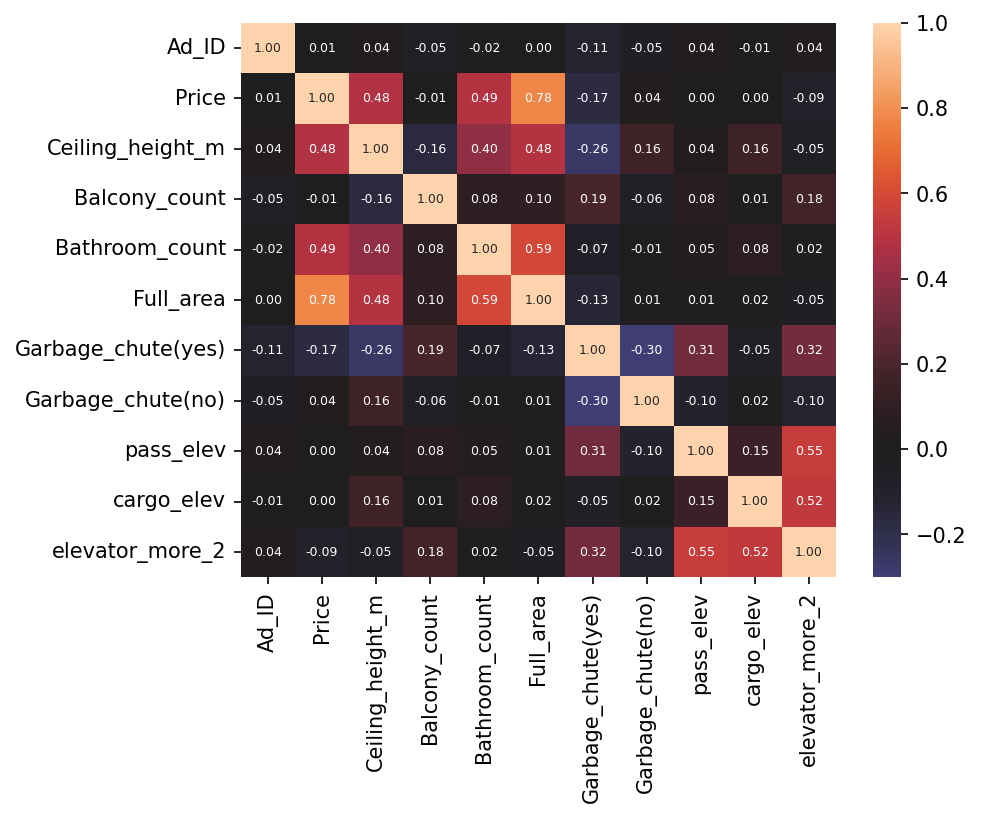

In [459]:
plt.figure(dpi=150)
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    center=0,
    fmt=".2f",
    annot_kws={'size': 6}
)

plt.show()

In [460]:
df["pass_elev"] = df["pass_elev"] [df["pass_elev"] < 12].astype(int)
df["cargo_elev"] = df["cargo_elev"][df["cargo_elev"] < 12].astype(int)
df["total_elev"] = df["pass_elev"] + df["cargo_elev"]


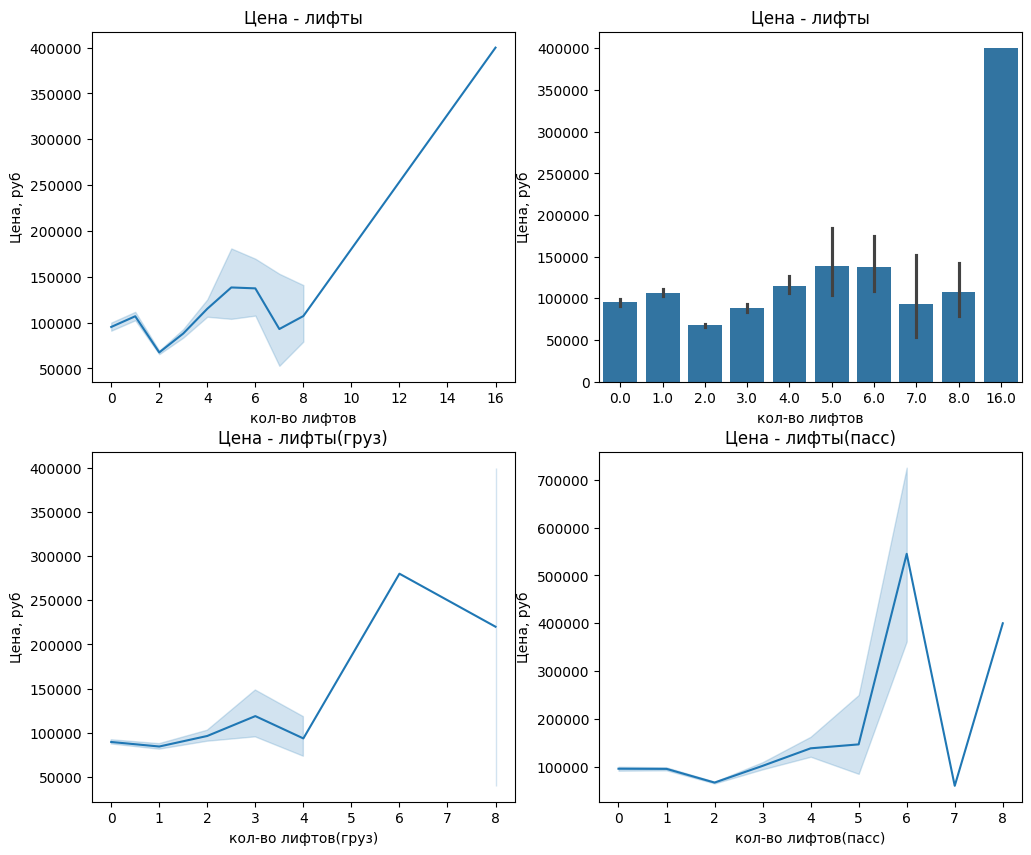

In [461]:
fix, axes = plt.subplots(2,2, figsize=(12,10))

sns.lineplot(data=df, x="total_elev", y="Price", ax=axes[0, 0])
sns.barplot(data=df, y="Price", x="total_elev", ax=axes[0, 1])

sns.lineplot(data=df, x="cargo_elev", y="Price", ax=axes[1, 0])
sns.lineplot(data=df, x="pass_elev", y="Price", ax=axes[1, 1])
axes[0, 0].set(title ='Цена - лифты' ,
    xlabel='кол-во лифтов',
    ylabel='Цена, руб'
               )
axes[0, 1].set(title ='Цена - лифты',
    xlabel='кол-во лифтов',
    ylabel='Цена, руб')
axes[1, 0].set(title ='Цена - лифты(груз)' ,
    xlabel='кол-во лифтов(груз)',
    ylabel='Цена, руб')
axes[1, 1].set(title ='Цена - лифты(пасс)' ,
    xlabel='кол-во лифтов(пасс)',
    ylabel='Цена, руб')
plt.show()

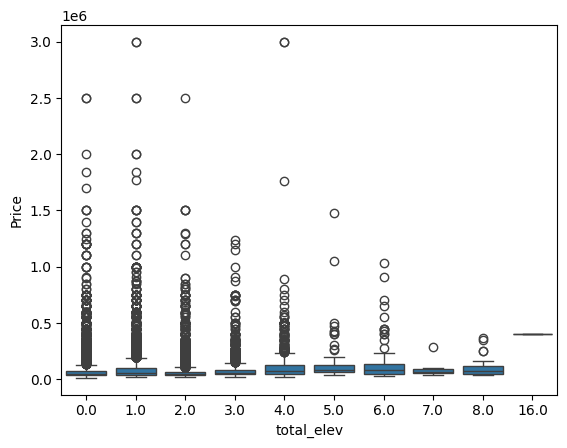

In [462]:
sns.boxplot(data=df, x="total_elev", y="Price")
plt.show()

In [463]:
df["trash_status"] = df["Garbage_chute(yes)"] + df["Garbage_chute(no)"]


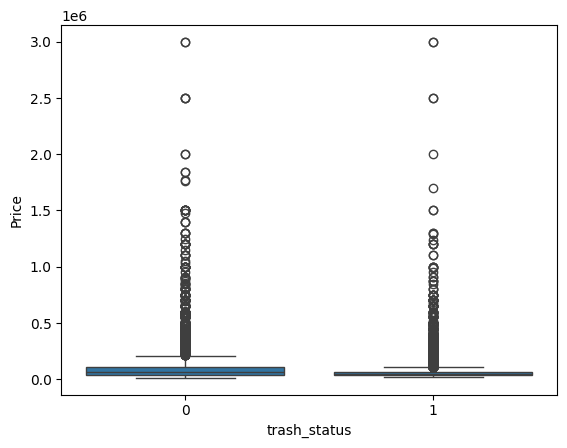

In [464]:
sns.boxplot(data=df, x="trash_status", y="Price")
plt.show()

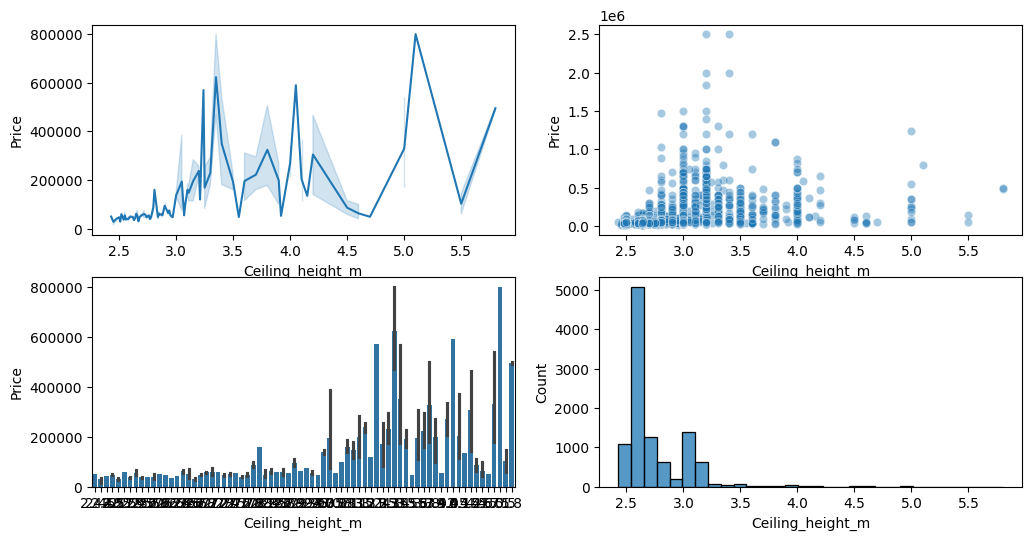

In [465]:
fix, axes = plt.subplots(2,2, figsize=(12,6))

sns.lineplot(data=df, x="Ceiling_height_m", y="Price", ax=axes[0, 0])
sns.scatterplot(data=df, x="Ceiling_height_m", y="Price", alpha=0.4, ax=axes[0, 1])
sns.histplot(df["Ceiling_height_m"], bins=30, ax=axes[1, 1])
sns.barplot(data=df, x="Ceiling_height_m", y="Price", ax=axes[1, 0])



plt.show()